<a href="https://colab.research.google.com/github/aamirrra02-stack/geospatial-building-detection/blob/main/main_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================
# Yolov8 Training Script
# ==========================================

# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Install Ultralytics
!pip install ultralytics

import os
from ultralytics import YOLO

# 3. SET YOUR DRIVE PATHS
DRIVE_BASE_PATH = '/content/drive/MyDrive/geospatial_project' # CHANGE THIS to your actual path
DATASET_PATH = os.path.join(DRIVE_BASE_PATH, 'datasets')
PROJECT_NAME = 'building_detection_yolov8'

# 4. CREATE THE data.yaml FILE
# YOLO models need a YAML file to tell them where the data is.
yaml_content = f"""
path: {DATASET_PATH} # dataset root dir
train: images/train  # train images (relative to path)
val: images/train    # val images (Using train for now since small dataset)

# Classes
names:
  0: building
"""

with open('data.yaml', 'w') as f:
    f.write(yaml_content)

print("✅ data.yaml created at:", os.path.abspath('data.yaml'))

# 5. INITIALIZE YOLOv8 MODEL (Nano version recommended for small datasets/speed)
model = YOLO('yolov8n.pt')

# 6. TRAIN THE MODEL (20 Epochs)
print("🚀 Starting YOLOv8 training...")
results = model.train(
    data='data.yaml',
    epochs=150,
    imgsz=640,
    batch=4,
    project=DRIVE_BASE_PATH, # Saves weights back to your Drive
    name=PROJECT_NAME,
    save=True
)

print(f"✅ Training complete. Weights saved to: {DRIVE_BASE_PATH}/{PROJECT_NAME}/weights/best.pt")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ data.yaml created at: /content/data.yaml
🚀 Starting YOLOv8 training...
Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, 

In [ ]:
# ==========================================
# Yolov11 Training Script
# ==========================================

# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Install Ultralytics (Latest covers YOLOv11)
!pip install ultralytics

import os
from ultralytics import YOLO

# 3. SET YOUR DRIVE PATHS
DRIVE_BASE_PATH = '/content/drive/MyDrive/geospatial_project' # CHANGE THIS
DATASET_PATH = os.path.join(DRIVE_BASE_PATH, 'datasets')
PROJECT_NAME = 'building_detection_yolov11'

# 4. CREATE THE data.yaml FILE
# We assume you are using the same dataset structure as before.
yaml_content = f"""
path: {DATASET_PATH} # dataset root dir
train: images/train  # train images
val: images/train    # val images (Using train for now)

# Classes
names:
  0: building
"""

with open('data.yaml', 'w') as f:
    f.write(yaml_content)

# 5. INITIALIZE YOLOv11 MODEL
# Initialize with yolov11 nano (pretrained)
model = YOLO('yolo11n.pt')

# 6. TRAIN THE MODEL (20 Epochs)
print("🚀 Starting YOLOv11 training...")
results = model.train(
    data='data.yaml',
    epochs=150,
    imgsz=640,
    batch=4,
    project=DRIVE_BASE_PATH, # Saves weights back to your Drive
    name=PROJECT_NAME,
    save=True
)

print(f"✅ Training complete. Weights saved to: {DRIVE_BASE_PATH}/{PROJECT_NAME}/weights/best.pt")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 Starting YOLOv11 training...
Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.9

In [ ]:
# ==========================================
# ResNet50-FasterRCNN Training Script (PyTorch)
# ==========================================

# 1. Mount Drive & Setup
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import torch
import torch.utils.data
from PIL import Image
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights

# 2. SET PATHS
DRIVE_BASE_PATH = '/content/drive/MyDrive/geospatial_project' # CHANGE THIS
IMAGES_DIR = os.path.join(DRIVE_BASE_PATH, 'datasets/images/train')
LABELS_DIR = os.path.join(DRIVE_BASE_PATH, 'datasets/labels/train')
MODEL_SAVE_PATH = os.path.join(DRIVE_BASE_PATH, 'resnet_faster_rcnn_best.pth')

# 3. DEFINE CUSTOM DATALOADER FOR YOLO-FORMAT LABELS
# ==========================================
# UPDATED RESNET DATALOADER (Handles empty/background images)
# ==========================================

class BuildingDataset(torch.utils.data.Dataset):
    def __init__(self, root_images, root_labels, transforms=None):
        self.root_images = root_images
        self.root_labels = root_labels
        self.transforms = transforms
        self.imgs = list(sorted(os.listdir(root_images)))

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_images, self.imgs[idx])
        label_path = os.path.join(self.root_labels, os.path.splitext(self.imgs[idx])[0] + ".txt")

        img = Image.open(img_path).convert("RGB")
        width, height = img.size

        boxes = []
        labels = []

        # Parse YOLO txt file if it exists
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    if not line.strip(): continue
                    cls, x_c, y_c, w, h = map(float, line.split())

                    # Convert normalized YOLO format back to absolute pixels
                    xmin = (x_c - w/2) * width
                    xmax = (x_c + w/2) * width
                    ymin = (y_c - h/2) * height
                    ymax = (y_c + h/2) * height

                    boxes.append([xmin, ymin, xmax, ymax])
                    labels.append(1) # 1 represents the building class

        # CRUCIAL FIX: Handle images that have no annotations (Background samples)
        if len(boxes) > 0:
            boxes = torch.as_tensor(boxes, dtype=torch.float32)
            labels = torch.ones((len(labels),), dtype=torch.int64)
            area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
            iscrowd = torch.zeros((len(labels),), dtype=torch.int64)
        else:
            # Create explicit 2D empty tensors to keep Faster R-CNN happy
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            area = torch.zeros((0,), dtype=torch.float32)
            iscrowd = torch.zeros((0,), dtype=torch.int64)

        image_id = torch.tensor([idx])

        target = {}
        target["boxes"] = boxes
        target["labels"] = labels
        target["image_id"] = image_id
        target["area"] = area
        target["iscrowd"] = iscrowd

        if self.transforms is not None:
            img = self.transforms(img)

        return img, target

    def __len__(self):
        return len(self.imgs)

# 4. DEFINE THE MODEL (FasterRCNN_ResNet50_FPN)
def get_resnet_model(num_classes):
    # load a model pre-trained on COCO
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)

    # get number of input features for the classifier
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    # replace the pre-trained head with a new one
    # num_classes includes the background (class 0) + building (class 1)
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    return model

# Setup transformations
def get_transform():
    transforms = []
    transforms.append(torchvision.transforms.ToTensor())
    return torchvision.transforms.Compose(transforms)

# 5. SETUP DEVICE AND TRAINING LOOPS
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using device: {device}")

# We have two classes: background (0) and building (1)
num_classes = 2
dataset = BuildingDataset(IMAGES_DIR, LABELS_DIR, get_transform())

# We are using all 55 for training for this example.
def collate_fn(batch):
    return tuple(zip(*batch))

data_loader = torch.utils.data.DataLoader(
    dataset, batch_size=4, shuffle=True, num_workers=2,
    collate_fn=collate_fn)

# 6. INITIALIZE RESNET MODEL
model = get_resnet_model(num_classes)
model.to(device)

# construct an optimizer
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)

# and a learning rate scheduler
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

# 7. TRAINING LOOP (20 Epochs)
num_epochs = 20
print(f"🚀 Starting ResNet Faster R-CNN training loop ({num_epochs} epochs)...")

for epoch in range(num_epochs):
    model.train()
    i = 0
    epoch_loss = 0
    for images, targets in data_loader:
        images = list(image.to(device) for image in images)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        epoch_loss += losses.item()

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        if i % 10 == 0:
             print(f"Epoch: [{epoch}] [{i}/{len(data_loader)}] Loss: {losses.item():.4f}")
        i += 1

    # update the learning rate
    lr_scheduler.step()
    print(f"Epoch {epoch} finished. Average Loss: {epoch_loss/len(data_loader):.4f}")

# 8. SAVE THE MODEL
torch.save(model.state_dict(), MODEL_SAVE_PATH)
print(f"✅ Training complete. Model saved to: {MODEL_SAVE_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda
🚀 Starting ResNet Faster R-CNN training loop (20 epochs)...
Epoch: [0] [0/14] Loss: 2.1104
Epoch: [0] [10/14] Loss: 1.3015
Epoch 0 finished. Average Loss: 0.7889
Epoch: [1] [0/14] Loss: 1.2083
Epoch: [1] [10/14] Loss: 0.9248
Epoch 1 finished. Average Loss: 0.5353
Epoch: [2] [0/14] Loss: 0.4563
Epoch: [2] [10/14] Loss: 0.5975
Epoch 2 finished. Average Loss: 0.5175
Epoch: [3] [0/14] Loss: 0.3083
Epoch: [3] [10/14] Loss: 0.4271
Epoch 3 finished. Average Loss: 0.5060
Epoch: [4] [0/14] Loss: 0.5758
Epoch: [4] [10/14] Loss: 0.8008
Epoch 4 finished. Average Loss: 0.4508
Epoch: [5] [0/14] Loss: 0.5651
Epoch: [5] [10/14] Loss: 0.3674
Epoch 5 finished. Average Loss: 0.4346
Epoch: [6] [0/14] Loss: 0.3502
Epoch: [6] [10/14] Loss: 0.4318
Epoch 6 finished. Average Loss: 0.4573
Epoch: [7] [0/14] Loss: 0.5210
Epoch: [7] [10/14] Loss: 0.3784
Epoch 7 finishe

In [1]:
!pip install torchmetrics pycocotools ultralytics pandas matplotlib

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device for evaluation: cuda
Loading trained models...
Evaluating models across 54 images...


/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:43: UserWarning: Encountered more than 100 detections in a single image. This means that certain detections with the lowest scores will be ignored, that may have an undesirable impact on performance. Please consider adjusting the `max_detection_threshold` to suit your use case. To disable this warning, set attribute class `warn_on_many_detections=False`, after initializing the metric.
  warnings.warn(*args, **kwargs)


Calculating final metrics...

 PERFORMANCE COMPARISON MATRIX 
                  Model  mAP @ 0.5  mAP @ 0.5:0.95  Recall (Max 100 Dets)
                 YOLOv8   0.694886        0.350742               0.514205
                YOLOv11   0.652397        0.297264               0.456534
ResNet50 (Faster R-CNN)   0.285956        0.089055               0.326136


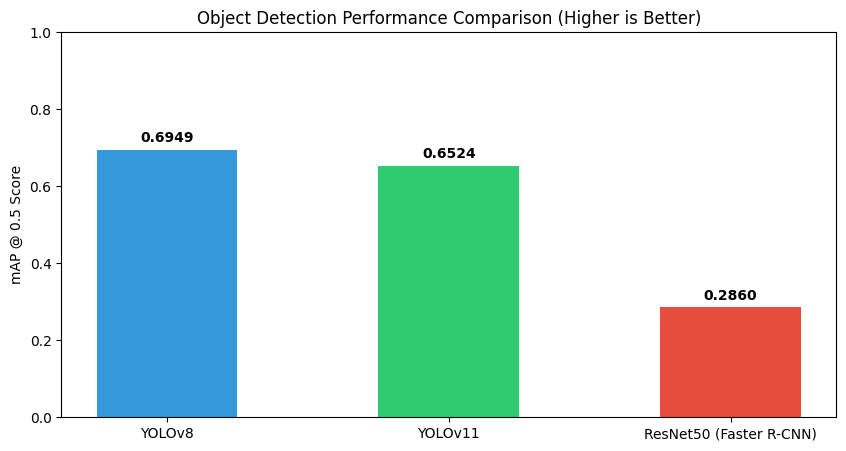

In [8]:
# ==========================================
# Unified Model Comparison Script
# ==========================================

# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
import torch
import torchvision
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# 2. CONFIGURATION PATHS
DRIVE_BASE_PATH = '/content/drive/MyDrive/geospatial_project' # CHANGE THIS to your path

IMAGES_DIR = os.path.join(DRIVE_BASE_PATH, 'datasets/images/train')
LABELS_DIR = os.path.join(DRIVE_BASE_PATH, 'datasets/labels/train')

YOLOv8_WEIGHTS = os.path.join(DRIVE_BASE_PATH, 'building_detection_yolov8-2/weights/best.pt')
YOLOv11_WEIGHTS = os.path.join(DRIVE_BASE_PATH, 'building_detection_yolov11-2/weights/best.pt')
RESNET_WEIGHTS = os.path.join(DRIVE_BASE_PATH, 'resnet_faster_rcnn_best.pth')

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using device for evaluation: {device}")

# 3. LOAD ALL THREE TRAINED MODELS
print("Loading trained models...")
model_v8 = YOLO(YOLOv8_WEIGHTS)
model_v11 = YOLO(YOLOv11_WEIGHTS)

# Rebuild ResNet architecture to load weights
def get_resnet_model(num_classes=2):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=None)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

model_resnet = get_resnet_model(num_classes=2)
model_resnet.load_state_dict(torch.load(RESNET_WEIGHTS, map_location=device))
model_resnet.to(device).eval()

# 4. INITIALIZE UNIFIED METRIC ENGINES
metric_v8 = MeanAveragePrecision(box_format='xyxy', iou_type='bbox')
metric_v11 = MeanAveragePrecision(box_format='xyxy', iou_type='bbox')
metric_resnet = MeanAveragePrecision(box_format='xyxy', iou_type='bbox')

# 5. EVALUATION LOOP OVER THE IMAGES
image_files = sorted([f for f in os.listdir(IMAGES_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
print(f"Evaluating models across {len(image_files)} images...")

resnet_transform = torchvision.transforms.ToTensor()

for img_name in image_files:
    img_path = os.path.join(IMAGES_DIR, img_name)
    label_path = os.path.join(LABELS_DIR, os.path.splitext(img_name)[0] + ".txt")

    # Read Image dimensions
    img_pil = Image.open(img_path).convert("RGB")
    width, height = img_pil.size

    # --- Parse Ground Truth ---
    gt_boxes = []
    gt_labels = []
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f.readlines():
                if not line.strip(): continue
                cls, x_c, y_c, w, h = map(float, line.split())
                # Convert normalized YOLO to absolute xyxy
                xmin = (x_c - w/2) * width
                xmax = (x_c + w/2) * width
                ymin = (y_c - h/2) * height
                ymax = (y_c + h/2) * height
                gt_boxes.append([xmin, ymin, xmax, ymax])
                gt_labels.append(1) # Building class is 1

    if len(gt_boxes) == 0:
        target_tensor = {'boxes': torch.zeros((0, 4), dtype=torch.float32), 'labels': torch.zeros((0,), dtype=torch.int64)}
    else:
        target_tensor = {'boxes': torch.tensor(gt_boxes, dtype=torch.float32), 'labels': torch.tensor(gt_labels, dtype=torch.int64)}

    target_list = [target_tensor]

    # --- 1. Evaluate YOLOv8 ---
    res_v8 = model_v8.predict(img_path, conf=0.1, verbose=False)[0]
    v8_boxes = res_v8.boxes.xyxy.cpu()
    v8_scores = res_v8.boxes.conf.cpu()
    v8_labels = torch.ones((len(v8_boxes),), dtype=torch.int64)
    metric_v8.update([{'boxes': v8_boxes, 'scores': v8_scores, 'labels': v8_labels}], target_list)

    # --- 2. Evaluate YOLOv11 ---
    res_v11 = model_v11.predict(img_path, conf=0.1, verbose=False)[0]
    v11_boxes = res_v11.boxes.xyxy.cpu()
    v11_scores = res_v11.boxes.conf.cpu()
    v11_labels = torch.ones((len(v11_boxes),), dtype=torch.int64)
    metric_v11.update([{'boxes': v11_boxes, 'scores': v11_scores, 'labels': v11_labels}], target_list)

    # --- 3. Evaluate ResNet (Faster R-CNN) ---
    img_tensor = resnet_transform(img_pil).to(device)
    with torch.no_grad():
        res_resnet = model_resnet([img_tensor])[0]
    resnet_boxes = res_resnet['boxes'].cpu()
    resnet_scores = res_resnet['scores'].cpu()
    resnet_labels = torch.ones((len(resnet_boxes),), dtype=torch.int64)
    metric_resnet.update([{'boxes': resnet_boxes, 'scores': resnet_scores, 'labels': resnet_labels}], target_list)

# 6. COMPUTE FINAL METRICS
print("Calculating final metrics...")
stats_v8 = metric_v8.compute()
stats_v11 = metric_v11.compute()
stats_resnet = metric_resnet.compute()

# 7. BUILD COMPARISON TABLE
results_data = {
    'Model': ['YOLOv8', 'YOLOv11', 'ResNet50 (Faster R-CNN)'],
    'mAP @ 0.5': [stats_v8['map_50'].item(), stats_v11['map_50'].item(), stats_resnet['map_50'].item()],
    'mAP @ 0.5:0.95': [stats_v8['map'].item(), stats_v11['map'].item(), stats_resnet['map'].item()],
    'Recall (Max 100 Dets)': [stats_v8['mar_100'].item(), stats_v11['mar_100'].item(), stats_resnet['mar_100'].item()]
}

df_compare = pd.DataFrame(results_data)
print("\n" + "="*50 + "\n PERFORMANCE COMPARISON MATRIX \n" + "="*50)
print(df_compare.to_string(index=False))
print("="*50)

# 8. PLOT THE GRAPH
plt.figure(figsize=(10, 5))
plt.bar(df_compare['Model'], df_compare['mAP @ 0.5'], color=['#3498db', '#2ecc71', '#e74c3c'], width=0.5)
plt.ylabel('mAP @ 0.5 Score')
plt.title('Object Detection Performance Comparison (Higher is Better)')
plt.ylim(0, 1.0)
for i, val in enumerate(df_compare['mAP @ 0.5']):
    plt.text(i, val + 0.02, f"{val:.4f}", ha='center', fontweight='bold')
plt.show()

In [9]:
# ==========================================
# YOLOv8 Kaggle CSV Submission Script (FIXED)
# ==========================================

from google.colab import drive
import os
import pandas as pd
from ultralytics import YOLO

# 1. MOUNT DRIVE AND SET PATHS
drive.mount('/content/drive', force_remount=True)

DRIVE_BASE_PATH = '/content/drive/MyDrive/geospatial_project'
TEST_IMAGES_DIR = os.path.join(DRIVE_BASE_PATH, 'datasets/images/test')

YOLOV8_WEIGHTS = os.path.join(DRIVE_BASE_PATH, 'building_detection_yolov8-2/weights/best.pt')
OUTPUT_CSV_PATH = os.path.join(DRIVE_BASE_PATH, 'yolov8_kaggle_submission.csv')

# 2. LOAD TRAINED MODEL
print(f"Loading YOLOv8 weights...")
model = YOLO(YOLOV8_WEIGHTS)

# 3. RUN INFERENCE & CONVERT
submission_rows = []
test_images = sorted([f for f in os.listdir(TEST_IMAGES_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

print(f"Processing {len(test_images)} images...")

for img_name in test_images:
    img_path = os.path.join(TEST_IMAGES_DIR, img_name)
    image_id = os.path.splitext(img_name)[0]

    results = model.predict(source=img_path, conf=0.15, save=False, verbose=False)
    result = results[0]

    prediction_strings = []
    if len(result.boxes) > 0:
        for box in result.boxes:
            cls = int(box.cls[0].item()) # Class ID (0 for building)
            conf = box.conf[0].item()    # Confidence score

            # Get normalized coordinates: x_center, y_center, width, height (0 to 1)
            xywhn = box.xywhn[0].cpu().numpy()
            x_c, y_c, w, h = xywhn

            prediction_strings.append(f"{cls} {conf:.6f} {x_c:.6f} {y_c:.6f} {w:.6f} {h:.6f}")

    # FIX: If empty, use a single space string " " to prevent Kaggle Null/NaN errors
    full_prediction_string = " ".join(prediction_strings) if prediction_strings else " "

    # FIX: Headers match exactly 'image_id' and 'prediction_string'
    submission_rows.append({"image_id": image_id, "prediction_string": full_prediction_string})

# 4. SAVE TO CSV
df_submission = pd.DataFrame(submission_rows)
df_submission.to_csv(OUTPUT_CSV_PATH, index=False)

print(f"\n✅ Fixed YOLOv8 CSV saved to: {OUTPUT_CSV_PATH}")
print(df_submission.head())

Mounted at /content/drive
Loading YOLOv8 weights...
Processing 844 images...

✅ Fixed YOLOv8 CSV saved to: /content/drive/MyDrive/geospatial_project/yolov8_kaggle_submission.csv
  image_id                                  prediction_string
0        1  0 0.572620 0.306130 0.616892 0.026049 0.022554...
1       10                                                   
2      100  0 0.892720 0.858588 0.472567 0.026109 0.044529...
3      101  0 0.642413 0.265947 0.776681 0.025145 0.024815...
4      102  0 0.816031 0.514892 0.436125 0.039841 0.043919...


In [10]:
# ==========================================
# YOLOv11 Kaggle CSV Submission Script (FIXED)
# ==========================================

from google.colab import drive
import os
import pandas as pd
from ultralytics import YOLO

# 1. MOUNT DRIVE AND SET PATHS
drive.mount('/content/drive', force_remount=True)

DRIVE_BASE_PATH = '/content/drive/MyDrive/geospatial_project'
TEST_IMAGES_DIR = os.path.join(DRIVE_BASE_PATH, 'datasets/images/test')

YOLOV11_WEIGHTS = os.path.join(DRIVE_BASE_PATH, 'building_detection_yolov11-2/weights/best.pt')
OUTPUT_CSV_PATH = os.path.join(DRIVE_BASE_PATH, 'yolov11_kaggle_submission.csv')

# 2. LOAD TRAINED MODEL
print(f"Loading YOLOv11 weights...")
model = YOLO(YOLOV11_WEIGHTS)

# 3. RUN INFERENCE & CONVERT
submission_rows = []
test_images = sorted([f for f in os.listdir(TEST_IMAGES_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

print(f"Processing {len(test_images)} images...")

for img_name in test_images:
    img_path = os.path.join(TEST_IMAGES_DIR, img_name)
    image_id = os.path.splitext(img_name)[0]

    results = model.predict(source=img_path, conf=0.15, save=False, verbose=False)
    result = results[0]

    prediction_strings = []
    if len(result.boxes) > 0:
        for box in result.boxes:
            cls = int(box.cls[0].item())
            conf = box.conf[0].item()

            xywhn = box.xywhn[0].cpu().numpy()
            x_c, y_c, w, h = xywhn

            prediction_strings.append(f"{cls} {conf:.6f} {x_c:.6f} {y_c:.6f} {w:.6f} {h:.6f}")

    # FIX: Space fallback for empty rows
    full_prediction_string = " ".join(prediction_strings) if prediction_strings else " "
    submission_rows.append({"image_id": image_id, "prediction_string": full_prediction_string})

# 4. SAVE TO CSV
df_submission = pd.DataFrame(submission_rows)
df_submission.to_csv(OUTPUT_CSV_PATH, index=False)

print(f"\n✅ Fixed YOLOv11 CSV saved to: {OUTPUT_CSV_PATH}")
print(df_submission.head())

Mounted at /content/drive
Loading YOLOv11 weights...
Processing 844 images...

✅ Fixed YOLOv11 CSV saved to: /content/drive/MyDrive/geospatial_project/yolov11_kaggle_submission.csv
  image_id                                  prediction_string
0        1  0 0.656269 0.218845 0.653394 0.060164 0.043340...
1       10                                                   
2      100     0 0.659617 0.856448 0.472475 0.025140 0.046981
3      101  0 0.757155 0.265279 0.777737 0.024906 0.027036...
4      102  0 0.764790 0.602498 0.236215 0.047421 0.049660...


In [6]:
# ==========================================
# ResNet50 Kaggle CSV Submission Script (FIXED)
# ==========================================

from google.colab import drive
import os
import torch
import torchvision
import pandas as pd
from PIL import Image
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

# 1. MOUNT DRIVE AND SET PATHS
drive.mount('/content/drive', force_remount=True)

DRIVE_BASE_PATH = '/content/drive/MyDrive/geospatial_project'
TEST_IMAGES_DIR = os.path.join(DRIVE_BASE_PATH, 'datasets/images/test')

RESNET_WEIGHTS = os.path.join(DRIVE_BASE_PATH, 'resnet_faster_rcnn_best.pth')
OUTPUT_CSV_PATH = os.path.join(DRIVE_BASE_PATH, 'resnet_kaggle_submission.csv')

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# 2. REBUILD RESNET ARCHITECTURE AND LOAD WEIGHTS
def get_resnet_model(num_classes=2):
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=None)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

print(f"Loading ResNet50 weights...")
model = get_resnet_model(num_classes=2)
model.load_state_dict(torch.load(RESNET_WEIGHTS, map_location=device))
model.to(device).eval()

resnet_transform = torchvision.transforms.ToTensor()

# 3. RUN INFERENCE & CONVERT
submission_rows = []
test_images = sorted([f for f in os.listdir(TEST_IMAGES_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

print(f"Processing {len(test_images)} images...")
CONFIDENCE_THRESHOLD = 0.15

for img_name in test_images:
    img_path = os.path.join(TEST_IMAGES_DIR, img_name)
    image_id = os.path.splitext(img_name)[0]

    img_pil = Image.open(img_path).convert("RGB")
    width, height = img_pil.size  # Need pixel sizes to normalize coordinates
    img_tensor = resnet_transform(img_pil).to(device)

    with torch.no_grad():
        prediction = model([img_tensor])[0]

    boxes = prediction['boxes'].cpu().numpy()
    scores = prediction['scores'].cpu().numpy()

    prediction_strings = []
    for i in range(len(scores)):
        if scores[i] >= CONFIDENCE_THRESHOLD:
            conf = scores[i]
            xmin, ymin, xmax, ymax = boxes[i]

            # Convert raw pixel coordinates to Normalized YOLO format
            box_w = xmax - xmin
            box_h = ymax - ymin
            x_center = xmin + (box_w / 2.0)
            y_center = ymin + (box_h / 2.0)

            # Scale from 0 to 1
            x_c_norm = x_center / width
            y_c_norm = y_center / height
            w_norm = box_w / width
            h_norm = box_h / height

            prediction_strings.append(f"0 {conf:.6f} {x_c_norm:.6f} {y_c_norm:.6f} {w_norm:.6f} {h_norm:.6f}")

    # FIX: Space fallback for empty predictions
    full_prediction_string = " ".join(prediction_strings) if prediction_strings else " "
    submission_rows.append({"image_id": image_id, "prediction_string": full_prediction_string})

# 4. SAVE TO CSV
df_submission = pd.DataFrame(submission_rows)
df_submission.to_csv(OUTPUT_CSV_PATH, index=False)

print(f"\n✅ Fixed ResNet50 CSV saved to: {OUTPUT_CSV_PATH}")
print(df_submission.head())

Mounted at /content/drive
Loading ResNet50 weights...
Processing 844 images...

✅ Fixed ResNet50 CSV saved to: /content/drive/MyDrive/geospatial_project/resnet_kaggle_submission.csv
  image_id                                  prediction_string
0        1  0 0.655626 0.219301 0.652144 0.045606 0.039562...
1       10  0 0.613002 0.545042 0.075800 0.027517 0.035562...
2      100  0 0.712519 0.011155 0.067611 0.021180 0.025093...
3      101  0 0.712143 0.268049 0.776300 0.022381 0.020671...
4      102  0 0.778425 0.607695 0.378157 0.017793 0.013179...
